# Assessment Notebook

This notebook implements the final three trading signals selected in the research notebook and evaluates the resulting combined trading strategy. The parameters are not re-estimated here; they are taken from the in-sample research process and applied directly in the assessment period.

The final signals are:

1. **Signal 0:** SPY / VIX term-structure signal.
2. **Signal 1:** XLE / Oil relative-strength signal.
3. **Signal 2:** GLD / Gold safe-haven signal.

The notebook first downloads the required market data, then computes the three signals, builds the combined portfolio, calculates performance statistics and finally visualizes the strategy behaviour.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import gridspec
%matplotlib inline

import importlib
import module
importlib.reload(module)

<module 'module' from 'C:\\Users\\Admin\\Desktop\\computational finance\\Github\\final draft\\module.py'>

# 1. Data Preparation

This section downloads the traded ETFs and the information variables used by the signals. The traded assets are SPY, XLE and GLD. AOR is used as the benchmark for the combined strategy.

In [2]:
# DOWNLOAD DATA

benchmark_ticker = "AOR"

download_tickers = [
    "SPY",
    "XLE",
    "GLD",
    benchmark_ticker
]

tickers = [
    "SPY_VIX",
    "XLE_OIL",
    "GLD_GOLD",
    benchmark_ticker
]

vix_ticker = "^VIX"
vix3m_ticker = "^VIX3M"
oil_ticker = "CL=F"
bond_ticker = "TLT"

indicator_tickers = [
    vix_ticker,
    vix3m_ticker,
    oil_ticker,
    bond_ticker
]

start_date = "2015-01-01"
end_date = "2025-12-31"

df_downloaded_prices, _ = module.download_stock_price_data(
    download_tickers,
    start_date,
    end_date
)

df_indicator_prices, _ = module.download_stock_price_data(
    indicator_tickers,
    start_date,
    end_date
)

common_index = df_downloaded_prices.index.intersection(
    df_indicator_prices.index
)

df_downloaded_prices = df_downloaded_prices.loc[common_index]
df_indicator_prices = df_indicator_prices.loc[common_index]

df_prices = pd.DataFrame(index=common_index)

df_prices["SPY_VIX"] = df_downloaded_prices["SPY"]
df_prices["XLE_OIL"] = df_downloaded_prices["XLE"]
df_prices["GLD_GOLD"] = df_downloaded_prices["GLD"]
df_prices[benchmark_ticker] = df_downloaded_prices[benchmark_ticker]

df_price_changes = module.price_changes_from_price_frame(df_prices)

print("First common date:", df_prices.index.min())
print("Last common date:", df_prices.index.max())

df_prices.tail()


First common date: 2015-01-02 00:00:00
Last common date: 2025-12-30 00:00:00


,SPY_VIX,XLE_OIL,GLD_GOLD,AOR
date,,,,
2025-12-23,684.323303,43.894577,413.640015,64.908707
2025-12-24,686.730530,43.766346,411.929993,65.097801
2025-12-26,686.660889,43.598660,416.739990,65.127663
2025-12-29,684.213867,44.012947,398.600006,65.038086
2025-12-30,683.378296,44.348320,398.890015,65.008232


# 2. Trading Signals

The following cells define the three final signal functions. The assessment notebook uses fixed parameter values that were selected in the research notebook. This keeps the out-of-sample assessment separate from the parameter search.

In [3]:
# DEFINE THREE TRADING SIGNALS

# Signal 0:
# Trades SPY using VIX term structure and SPY momentum.

# Signal 1:
# Trades XLE using crude oil momentum, XLE trend, XLE momentum,
# and XLE relative strength versus SPY.

# Signal 2:
# Trades GLD using gold trend, gold momentum, and Treasury bond momentum.


## Signal 0: SPY / VIX Term-Structure Signal

The strategy trades SPY. The VIX index and the VIX3M index are not traded directly; they are only used as information variables.

The economic idea is that the VIX term structure contains information about the equity-market risk regime. The signal is active when the VIX3M/VIX ratio is above the selected threshold and SPY momentum is not too weak. This means the strategy buys SPY only when the volatility environment is sufficiently normal and the underlying equity market does not show strong medium-term weakness.

In [4]:
signal_0_ratio_threshold = 1.10
signal_0_momentum_window = 168
signal_0_momentum_threshold = -0.025


def signal_0(series):

    return module.vix_term_structure_signal(
        target_series=series,
        vix_series=df_indicator_prices[vix_ticker],
        vix3m_series=df_indicator_prices[vix3m_ticker],
        ratio_threshold=signal_0_ratio_threshold,
        momentum_window=signal_0_momentum_window,
        momentum_threshold=signal_0_momentum_threshold
    )

## Signal 1: Oil / Energy Relative-Strength Signal

The strategy trades XLE. Crude oil futures and SPY are not traded directly; they are only used as information variables.

The signal is active when XLE is in an upward trend, crude oil momentum is not too weak, XLE has positive own momentum, and XLE does not strongly underperform SPY. The aim is to hold energy equities only when both the sector itself and the oil-related market environment are supportive.

In [5]:
signal_1_trend_window = 200

signal_1_oil_momentum_window = 126
signal_1_oil_momentum_threshold = -0.05

signal_1_target_momentum_window = 210
signal_1_target_momentum_threshold = 0.0

signal_1_relative_strength_window = 21
signal_1_relative_strength_threshold = -0.025


def signal_1(series):

    return module.oil_energy_relative_strength_signal(
        target_series=series,
        oil_series=df_indicator_prices[oil_ticker],
        market_series=df_downloaded_prices["SPY"],
        trend_window=signal_1_trend_window,
        oil_momentum_window=signal_1_oil_momentum_window,
        oil_momentum_threshold=signal_1_oil_momentum_threshold,
        target_momentum_window=signal_1_target_momentum_window,
        target_momentum_threshold=signal_1_target_momentum_threshold,
        relative_strength_window=signal_1_relative_strength_window,
        relative_strength_threshold=signal_1_relative_strength_threshold
    )

## Signal 2: Gold Safe-Haven Signal

The strategy trades GLD. TLT is not traded directly; it is only used as an information variable for the bond and interest-rate environment.

The signal is active when GLD is above its long-term moving average, GLD has positive medium-term momentum, and TLT momentum is not strongly negative. Gold is included because it adds a different return driver to the equity-oriented SPY and XLE signals.

In [6]:
signal_2_trend_window = 100
signal_2_momentum_window = 63
signal_2_gld_momentum_threshold = 0.0
signal_2_tlt_momentum_threshold = -0.02


def signal_2(series):

    return module.gold_safe_haven_signal(
        gld_series=series,
        tlt_series=df_indicator_prices[bond_ticker],
        trend_window=signal_2_trend_window,
        momentum_window=signal_2_momentum_window,
        gld_momentum_threshold=signal_2_gld_momentum_threshold,
        tlt_momentum_threshold=signal_2_tlt_momentum_threshold
    )


In [7]:
signals = {
    tickers[0]: signal_0(df_prices[tickers[0]]),
    tickers[1]: signal_1(df_prices[tickers[1]]),
    tickers[2]: signal_2(df_prices[tickers[2]])
}

execution_delay_days = 1

for ticker in tickers[:-1]:

    signals[ticker] = module.apply_execution_delay(
        signals[ticker],
        delay_days=execution_delay_days
    )

df_position_open = pd.concat([
    signals[tickers[0]]["signal"].rename(tickers[0]),
    signals[tickers[1]]["signal"].rename(tickers[1]),
    signals[tickers[2]]["signal"].rename(tickers[2])
], axis=1)

df_position_changes = pd.concat([
    signals[tickers[0]]["position_change"].rename(tickers[0]),
    signals[tickers[1]]["position_change"].rename(tickers[1]),
    signals[tickers[2]]["position_change"].rename(tickers[2])
], axis=1)

df_position_open.tail()

,SPY_VIX,XLE_OIL,GLD_GOLD
date,,,
2025-12-23,1.0,0.0,1.0
2025-12-24,1.0,0.0,1.0
2025-12-26,1.0,0.0,1.0
2025-12-29,1.0,0.0,1.0
2025-12-30,1.0,0.0,1.0


# 3. Portfolio Construction

The three binary signals are combined into one portfolio. A fixed fraction of available capital is allocated when a signal opens, positions are held while the signal remains active, and capital is returned to cash when a signal closes.

In [8]:
# ALLOCATE CAPITAL AND COMPUTE RESULTING POSITIONS
initial_cash = 1.0
capital_fraction_per_trade = 0.30

# Portfolio mechanics
position = []

def open_trades(position, position_change):
    vec = np.maximum([position_change[ticker] for ticker in tickers[:-1]], [0])
    vec = position[-1] * (1 - np.power((1 - capital_fraction_per_trade), np.sum(vec))) * vec / (1 if (np.nansum(vec) == 0.0) else np.nansum(vec))
    return np.append(vec + position[:-1], position[-1] - np.sum(vec))

def hold_trades(position, price_change):
    return np.concatenate((position[:-1] * price_change[:-1], [position[-1]]))

def close_trades(position, position_change):
    vec = np.concatenate((np.array([position_change[ticker] < 0.0 for ticker in tickers[:-1]]), [False]))
    position[-1] = position[-1] + np.sum(position[vec])
    position[vec] = 0.0
    return position
    
is_first = True
for idx, position_change in df_position_changes.iterrows():
    if is_first:
        position.append(open_trades(np.concatenate((np.zeros(len(df_position_changes.columns)), [initial_cash])), position_change))
        is_first = False
    else:
        hlpr_pos = hold_trades(position[-1], df_price_changes.loc[[idx]].to_numpy()[0])
        hlpr_pos = close_trades(hlpr_pos, position_change)
        position.append(open_trades(hlpr_pos, position_change))

df_position = pd.DataFrame(position, index = df_prices.index, columns = tickers[:-1] + ['cash'])

# 4. Performance Statistics

The combined strategy is compared with the AOR benchmark using annualized return, annualized volatility, Sharpe ratio and maximum drawdown.

C:\Users\Admin\AppData\Local\Temp\ipykernel_18996\3734850038.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=8)


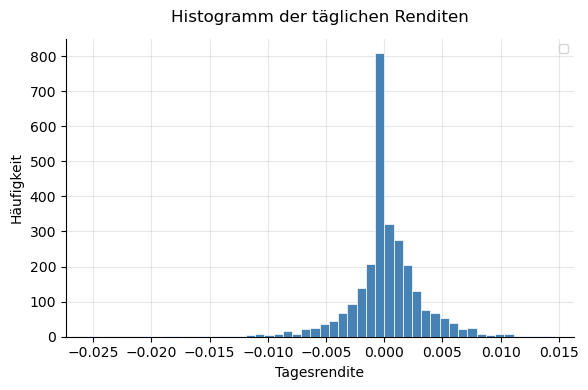

In [9]:
statistics_rows = {}

portfolio_value = df_position.sum(axis=1).to_numpy(dtype=float)

statistics_rows["Our Strategy"] = (
    module.performance_statistics_from_values(
        portfolio_value
    )
)

benchmark_values = df_prices[tickers[-1]].to_numpy(dtype=float)

benchmark_curve = (
    benchmark_values
    / benchmark_values[0]
)

statistics_rows["Benchmark AOR ETF"] = (
    module.performance_statistics_from_values(
        benchmark_curve
    )
)

df_statistics = pd.DataFrame(statistics_rows).T

df_statistics = df_statistics[
    [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ]
]

df_statistics.T.round(4)


# Histogram
returns = module.portfolio_returns_from_values(portfolio_value)

plt.figure(figsize=(6, 4))

plt.hist(returns, bins=50, color="steelblue", edgecolor="white", linewidth=0.5, zorder=3)
plt.title("Histogramm der täglichen Renditen", pad=12)
plt.xlabel("Tagesrendite")
plt.ylabel("Häufigkeit")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3, zorder=0)

plt.gca().spines["top"].set_visible(False)    
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# 5. Graphical Analysis

The graphs illustrate the portfolio value, drawdowns, rolling risk-adjusted performance, signal activity, capital allocation and buy/sell timing for the three final signals.

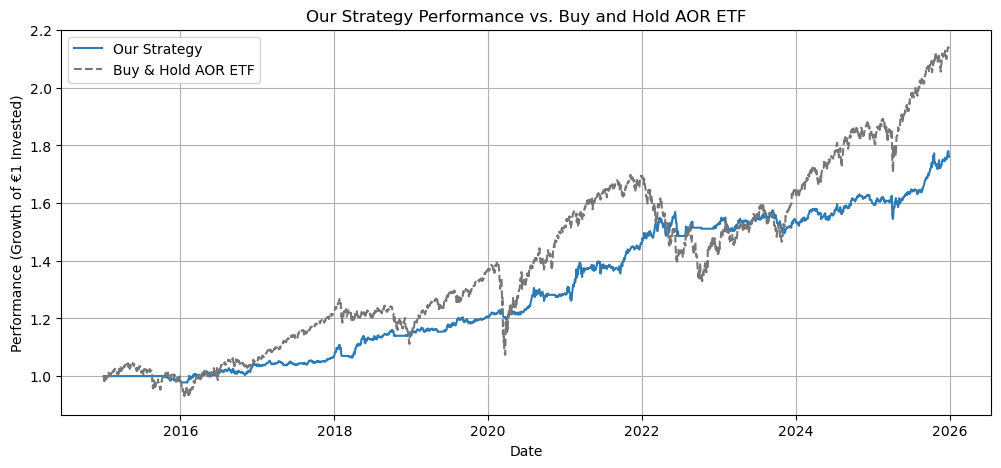

In [10]:
# COMPUTE MEANINGFUL PLOTS OF YOUR STRATEGY AND LABEL THEM IN AN UNDERSTANDABLE WAY

portfolio_value = df_position.sum(axis=1).to_numpy(dtype=float)

portfolio_curve = (
    portfolio_value
    / portfolio_value[0]
)

benchmark_values = df_prices[tickers[-1]].to_numpy(dtype=float)

benchmark_curve = (
    benchmark_values
    / benchmark_values[0]
)

plt.figure(figsize=(12, 5))

plt.plot(
    df_prices.index,
    portfolio_curve,
    label="Our Strategy", 
    color = "#2c7bb6"
)

plt.plot(
    df_prices.index,
    benchmark_curve,
    label="Buy & Hold " + tickers[-1]+ " ETF",
    linestyle="--",
    color = "#777777"
)

plt.title("Our Strategy Performance vs. Buy and Hold AOR ETF") # Out-of sample time
plt.xlabel("Date")
plt.ylabel("Performance (Growth of €1 Invested)")
plt.legend()
plt.grid(True)

plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_18996\548140168.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.{decimals}f}%" for v in ax.get_yticks()])


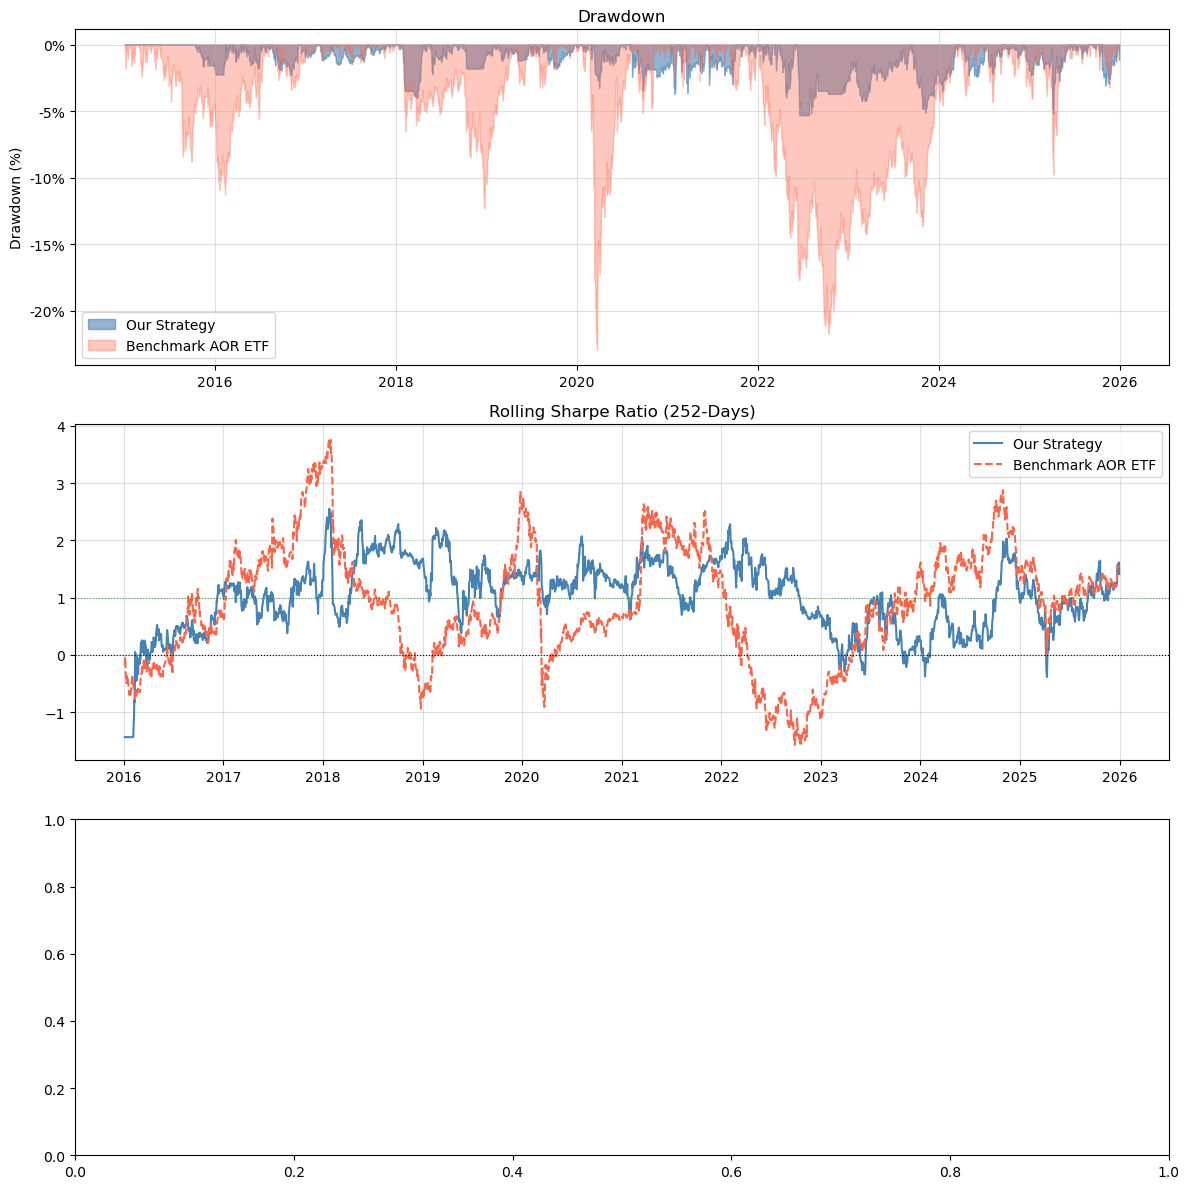

In [11]:
## Grafiken Neu:
dates  = df_prices.index.to_numpy()

port   = np.array(portfolio_curve)
bench  = np.array(benchmark_curve)

port_ret  = np.diff(port)  / port[:-1]
bench_ret = np.diff(bench) / bench[:-1]
dates_ret = dates[1:]

prices = {t: df_prices[t].to_numpy()          for t in tickers[:-1]}
signal = {t: df_position_open[t].to_numpy()   for t in tickers[:-1]}
change = {t: df_position_changes[t].to_numpy() for t in tickers[:-1]}

alloc_cols   = tickers[:-1] + ["cash"]
alloc        = np.column_stack([df_position[c].to_numpy() for c in alloc_cols])
alloc_pct    = alloc / alloc.sum(axis=1, keepdims=True) * 100

colors_sig   = ["steelblue", "darkorange", "seagreen"]
signal_names = ["SPY / VIX", "XLE / Öl", "ITA / Defensiv"]


def drawdown(curve):
    return (curve - np.maximum.accumulate(curve)) / np.maximum.accumulate(curve) * 100

def rolling_sharpe(ret, w=252):
    n   = len(ret)
    out = np.full(n, np.nan)
    for i in range(w, n):
        r = ret[i-w:i]
        out[i] = (r.mean() * 252) / (r.std() * np.sqrt(252))
    return out

def normal_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

def pct_labels(ax, axis="y", decimals=0):
    if axis == "y":
        ax.set_yticklabels([f"{v:.{decimals}f}%" for v in ax.get_yticks()])
    else:
        ax.set_xticklabels([f"{v:.{decimals}f}%" for v in ax.get_xticks()])

def yearly_return(ret, dates):
    years  = np.array([d.year for d in dates])
    unique = sorted(set(years))
    result = {}
    for y in unique:
        mask     = years == y
        result[y] = (np.prod(1 + ret[mask]) - 1) * 100
    return result


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 1 – Drawdown
# ═══════════════════════════════════════════════════════════════════════════

fig, (axes1, axes2, axes3) = plt.subplots(3,1,figsize=(12, 12))
axes1.fill_between(dates, drawdown(port),  alpha=0.6,  color="steelblue", label="Our Strategy")
axes1.fill_between(dates, drawdown(bench), alpha=0.35, color="tomato",    label="Benchmark AOR ETF")
pct_labels(axes1)
axes1.set_title("Drawdown")
axes1.set_ylabel("Drawdown (%)")
axes1.legend(); axes1.grid(alpha=0.4)
plt.tight_layout(); 


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 2 – Rolling Sharpe Ratio
# ═══════════════════════════════════════════════════════════════════════════

axes2.plot(dates_ret, rolling_sharpe(port_ret),  color="steelblue", label="Our Strategy")
axes2.plot(dates_ret, rolling_sharpe(bench_ret), color="tomato", linestyle="--", label="Benchmark AOR ETF")
axes2.axhline(0, color="black", linewidth=0.8, linestyle=":")
axes2.axhline(1, color="green", linewidth=0.8, linestyle=":", alpha=0.6)
axes2.set_title("Rolling Sharpe Ratio (252-Days)")
axes2.legend(); axes2.grid(alpha=0.4)
plt.tight_layout(); 
plt.show()

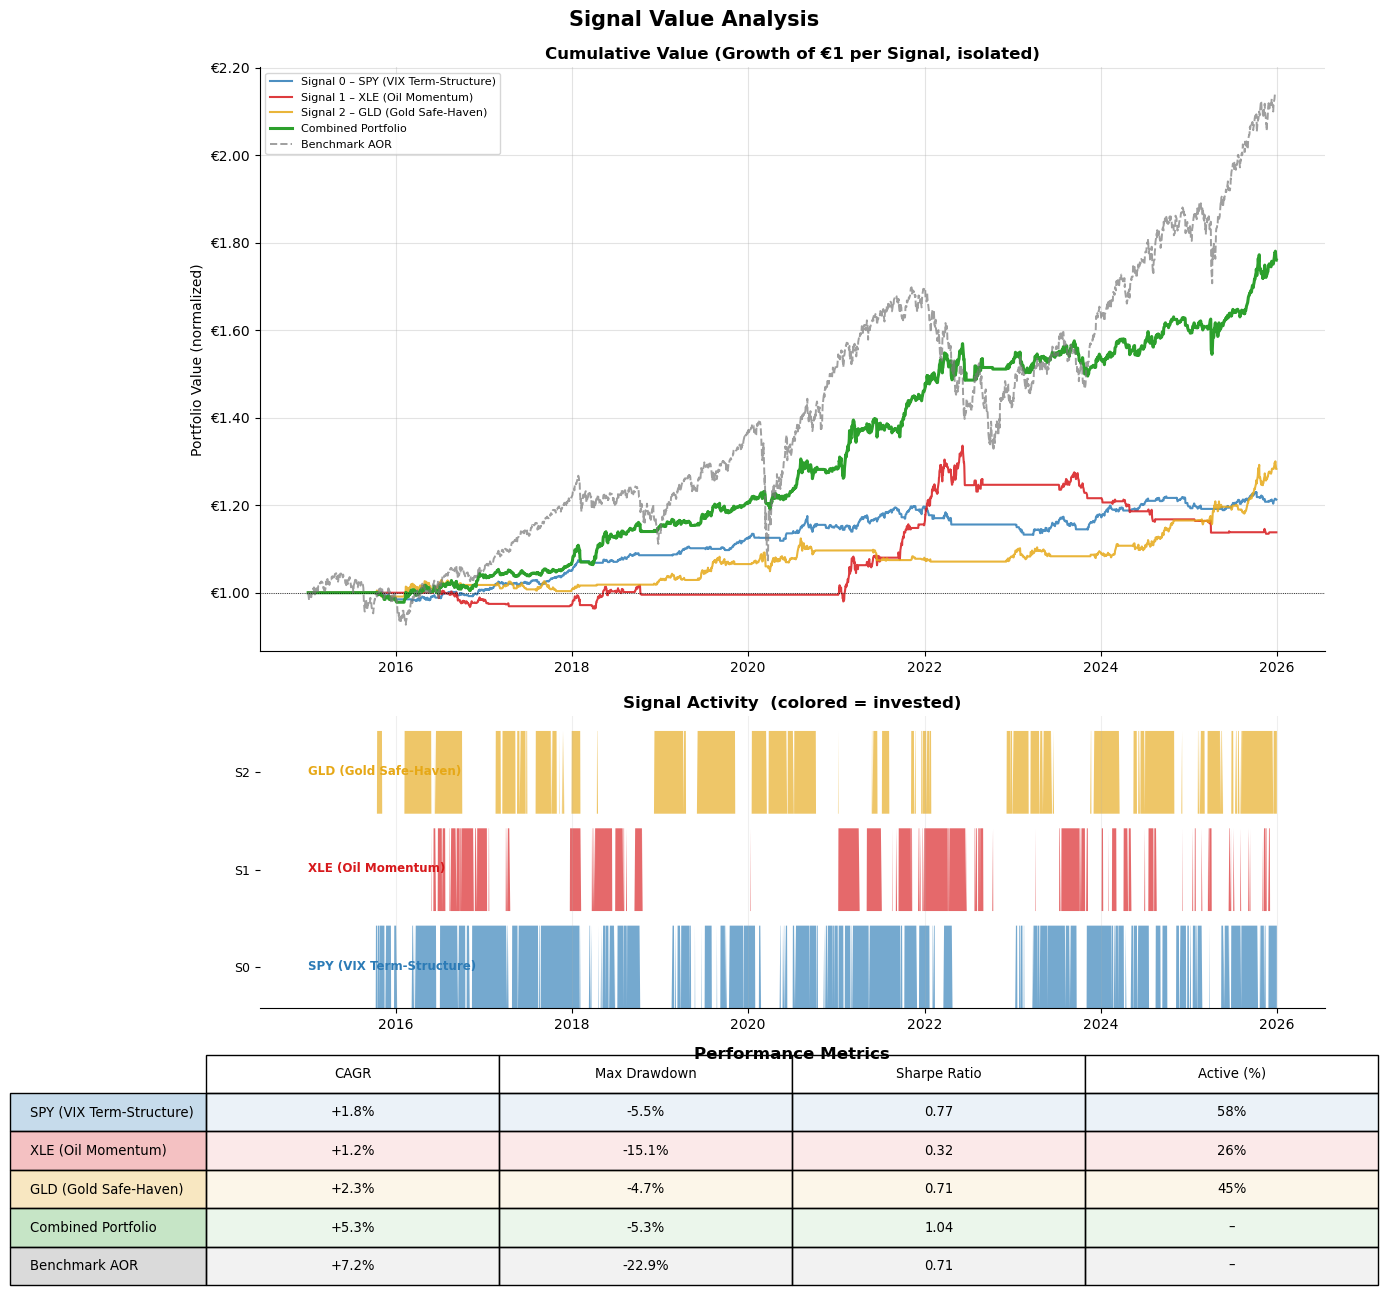

In [15]:
# Graphs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Helper: simulate each signal in isolation ─────────────────────────────────

def simulate_single_signal(ticker, capital_fraction=0.30):
    pos_invested, pos_cash = 0.0, initial_cash
    values = []
    for idx in df_prices.index:
        chg = df_position_changes.loc[idx, ticker]
        pc  = df_price_changes.loc[idx, ticker]
        if chg < 0 and pos_invested > 0:
            pos_cash += pos_invested; pos_invested = 0.0
        if pos_invested > 0:
            pos_invested *= pc
        if chg > 0 and pos_cash > 0:
            amount = pos_cash * capital_fraction
            pos_invested += amount; pos_cash -= amount
        values.append(pos_invested + pos_cash)
    curve = pd.Series(values, index=df_prices.index)
    return curve / curve.iloc[0]

signal_curves = {t: simulate_single_signal(t) for t in tickers[:-1]}

port_vals  = df_position.sum(axis=1)
port_curve = port_vals / port_vals.iloc[0]
bench_vals = df_prices[tickers[-1]]
bench_curve = bench_vals / bench_vals.iloc[0]
dates = df_prices.index

# ── Metrics ───────────────────────────────────────────────────────────────────

def cagr(c):
    n = (c.index[-1] - c.index[0]).days / 365.25
    return (c.iloc[-1] ** (1 / n) - 1) * 100

def max_dd(c):
    arr = np.array(c); peak = np.maximum.accumulate(arr)
    return ((arr - peak) / peak * 100).min()

def sharpe(c):
    r = c.pct_change().dropna()
    return (r.mean() * 252) / (r.std() * np.sqrt(252))

# ── Style ─────────────────────────────────────────────────────────────────────

COLORS = {
    "SPY_VIX":  "#2c7bb6",
    "XLE_OIL":  "#d7191c",
    "GLD_GOLD": "#e6a817",
    "Combined": "#2ca02c",
    "Benchmark":"#777777",
}
LABELS = {
    "SPY_VIX":  "Signal 0 – SPY (VIX Term-Structure)",
    "XLE_OIL":  "Signal 1 – XLE (Oil Momentum)",
    "GLD_GOLD": "Signal 2 – GLD (Gold Safe-Haven)",
    "Combined": "Combined Portfolio",
    "Benchmark":"Benchmark AOR",
}

# ── Figure ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 13),
                          gridspec_kw={"height_ratios": [3, 1.5, 1]})
fig.suptitle("Signal Value Analysis", fontsize=15, fontweight="bold", y=0.99)

ax_perf, ax_heat, ax_tbl = axes

# Panel 1 – Cumulative Value
for t in tickers[:-1]:
    ax_perf.plot(dates, signal_curves[t], color=COLORS[t],
                 label=LABELS[t], linewidth=1.5, alpha=0.85)
ax_perf.plot(dates, port_curve,  color=COLORS["Combined"],  linewidth=2.2, label=LABELS["Combined"])
ax_perf.plot(dates, bench_curve, color=COLORS["Benchmark"], linewidth=1.4,
             linestyle="--", alpha=0.7, label=LABELS["Benchmark"])
ax_perf.axhline(1, color="black", linewidth=0.6, linestyle=":")
ax_perf.set_title("Cumulative Value (Growth of €1 per Signal, isolated)", fontweight="bold")
ax_perf.set_ylabel("Portfolio Value (normalized)")
ax_perf.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:.2f}"))
ax_perf.legend(fontsize=8); ax_perf.grid(alpha=0.35)
ax_perf.spines[["top", "right"]].set_visible(False)

# Panel 2 – Signal Activity
for i, t in enumerate(tickers[:-1]):
    active = df_position_open[t].values.astype(float)
    ax_heat.fill_between(dates, i, i + active * 0.85,
                         color=COLORS[t], alpha=0.65, linewidth=0)
    ax_heat.text(dates[0], i + 0.43, LABELS[t].split("–")[1].strip(),
                 fontsize=8.5, va="center", color=COLORS[t], fontweight="bold")
ax_heat.set_yticks([0.42, 1.42, 2.42])
ax_heat.set_yticklabels(["S0", "S1", "S2"], fontsize=9)
ax_heat.set_ylim(0, 3)
ax_heat.set_title("Signal Activity  (colored = invested)", fontweight="bold")
ax_heat.grid(alpha=0.2, axis="x")
ax_heat.spines[["top", "right", "left"]].set_visible(False)

# Panel 3 – Metrics Table
items = list(tickers[:-1]) + ["Combined", "Benchmark"]
all_curves = {**signal_curves, "Combined": port_curve, "Benchmark": bench_curve}
col_labels = ["CAGR", "Max Drawdown", "Sharpe Ratio", "Active (%)"]

data = []
for key in items:
    c   = all_curves[key]
    act = f"{df_position_open[key].mean()*100:.0f}%" if key in tickers[:-1] else "–"
    data.append([f"{cagr(c):+.1f}%", f"{max_dd(c):.1f}%", f"{sharpe(c):.2f}", act])

ax_tbl.axis("off")
tbl = ax_tbl.table(
    cellText=data,
    rowLabels=[LABELS[k].split("–")[-1].strip() for k in items],
    colLabels=col_labels,
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1.1, 1.9)
for i, key in enumerate(items):
    tbl[(i+1, -1)].set_facecolor(COLORS[key] + "44")
    for j in range(len(col_labels)):
        tbl[(i+1, j)].set_facecolor(COLORS[key] + "18")
ax_tbl.set_title("Performance Metrics", fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("signal_value_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
